In [27]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.9 MB 1.8 MB/s eta 0:00:06
   -- ------------------------------------- 0.6/9.9 MB 5.7 MB/s eta 0:00:02
   --------------- ------------------------ 3.9/9.9 MB 24.9 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.9 MB 45.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 39.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/444.9 kB ? eta -:--:--
   --------------------------------------- 444.9/444.9 kB 27.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import numpy as np
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
mylist = [10, 33, 42, 56]
mylist = np.random.shuffle(np.array(mylist))
print(mylist)

None


In [ ]:
df = pd.read_csv("united_summer2015-1-1.csv")
df.head()

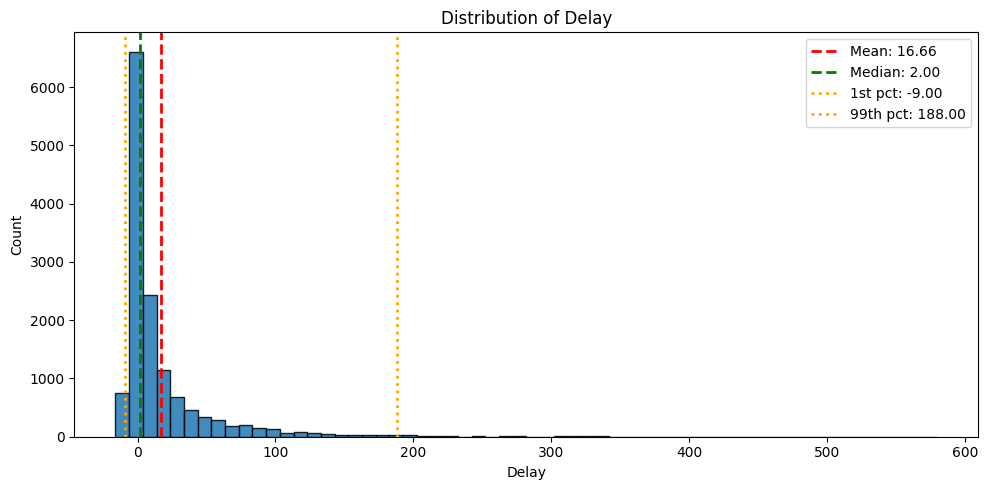

Count:   13825
Mean:    16.6582
Median:  2.0000
Std:     39.4816
Min:     -16.0000
Q1:      -2.0000
Q3:      18.0000
99th %:  188.0000
Max:     580.0000
Skew:    4.3006
Kurtosis:28.3220


In [34]:
# Use existing target_col ('Delay') from the notebook
target_col = "Delay"
series = df[target_col].dropna()

mean_val = series.mean()
median_val = series.median()
std_val = series.std()
q01 = series.quantile(0.01)
q25 = series.quantile(0.25)
q75 = series.quantile(0.75)
q99 = series.quantile(0.99)
min_val = series.min()
max_val = series.max()

plt.figure(figsize=(10, 5))
plt.hist(series, bins=60, alpha=0.85, edgecolor="black")
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color="green", linestyle="--", linewidth=2, label=f"Median: {median_val:.2f}")
plt.axvline(q01, color="orange", linestyle=":", linewidth=2, label=f"1st pct: {q01:.2f}")
plt.axvline(q99, color="orange", linestyle=":", linewidth=2, label=f"99th pct: {q99:.2f}")
plt.title(f"Distribution of {target_col}")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Count:   {series.count()}")
print(f"Mean:    {mean_val:.4f}")
print(f"Median:  {median_val:.4f}")
print(f"Std:     {std_val:.4f}")
print(f"Min:     {min_val:.4f}")
print(f"Q1:      {q25:.4f}")
print(f"Q3:      {q75:.4f}")
print(f"99th %:  {q99:.4f}")
print(f"Max:     {max_val:.4f}")
print(f"Skew:    {series.skew():.4f}")
print(f"Kurtosis:{series.kurt():.4f}")

In [38]:
above_200_count = (series > 200).sum()
total_count = series.count()
above_200_pct = (above_200_count / total_count) * 100

print(f"Values above 200: {above_200_count}/{total_count} ({above_200_pct:.2f}%)")

Values above 200: 116/13825 (0.84%)


In [39]:
between_0_10_count = series.between(0, 10, inclusive="both").sum()
between_0_10_pct = (between_0_10_count / total_count) * 100

print(f"Values between 0 and 10: {between_0_10_count}/{total_count} ({between_0_10_pct:.2f}%)")

Values between 0 and 10: 4261/13825 (30.82%)


In [42]:
sample_size = 1000
sample = df[target_col].dropna().sample(n=sample_size, random_state=42)
sample_median = sample.median()

print(f"Sample median (n={sample_size}) for {target_col}: {sample_median}")

Sample median (n=1000) for Delay: 2.0
